In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
import joblib

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

generate variables as paths

In [2]:
models_dir = Path("../models")
data_dir = Path("../data")

now load models and data using paths

In [4]:
lr_loaded = joblib.load(models_dir / "linear_regression.joblib")
rf_loaded = joblib.load(models_dir / "random_forest_regressor.joblib")
hgb_loaded = joblib.load(models_dir / "hist_gradient_boosting_regressor.joblib")
xgb_loaded = joblib.load(models_dir / "xgboost_regressor.joblib")
scaler_loaded = joblib.load(models_dir / "scaler.joblib")

nn_loaded = tf.keras.models.load_model(
    models_dir / "neural_network.keras"
)

df = pd.read_parquet(data_dir / 'processed/solar_clean.parquet')

take only records for 2023

In [6]:
df_23 = df[
    df['timestamp'] >= '2023-01-01'
].copy()

df_23 = df_23[
    [
        "timestamp",
        "irradiance",
        "ambient_temp",
        "module_temp_mean",
        "ac_power"
    ]
]

i will create now a forecast for variables irradiance and ambient temperature for next 7 days, the idea is to generate a dataset based on real data we have for january and february of 2023 that show a forecast simulation of irradiance and ambient temperature every 7 days

this way we can simulate what happen on our prediction of ac power if we had only a forecast once every week, adding stocastic variation with an increasing indetermination in forecast of the last days of the week, that means that every day of the week is more complicated to calculate with accuracy irradiance and temperature (an aproximation to real life forecasting) but without random noise

i will build a function that give as a forecast for the next 7 days, as we have records for every minute, is better to do the calculation for every 30 minutes and then do an interpolation between them to make an easier forecast model

In [8]:
def generate_forecast(
    df,
    forecast_date,
    horizon_days=7,
    random_state=None
):
    """
    Generate a smooth pseudo-forecast for the next 7 days.

    Forecast uncertainty increases with lead time.
    A stochastic error determines the actual deviation.
    30-minute anchor forecasts are interpolated to 1-minute data.
    """

    rng = np.random.default_rng(random_state)

    forecast_date = pd.Timestamp(forecast_date)

    # ==================================================
    # 1. Select the forecast period
    # ==================================================

    start = forecast_date + pd.Timedelta(minutes=1)
    end = forecast_date + pd.Timedelta(days=horizon_days)

    future = df[
        (df["timestamp"] >= start) &
        (df["timestamp"] <= end)
    ][
        [
            "timestamp",
            "irradiance",
            "ambient_temp",
            "module_temp_mean",
            "ac_power"
        ]
    ].copy()

    # ==================================================
    # 2. Create 30-minute anchor points
    # ==================================================

    anchors = (
        future
        .set_index("timestamp")
        [["irradiance", "ambient_temp"]]
        .resample("30min")
        .mean()
        .dropna()
        .reset_index()
    )

    # Forecast horizon in hours
    anchors["lead_hours"] = (
        anchors["timestamp"] - forecast_date
    ).dt.total_seconds() / 3600

    # ==================================================
    # 3. Increasing uncertainty with lead time
    # ==================================================

    max_lead = horizon_days * 24

    # Irradiance uncertainty: 2% -> 20%
    irradiance_sigma = np.interp(
        anchors["lead_hours"],
        [0, max_lead],
        [0.02, 0.20]
    )

    # Ambient temperature uncertainty: 0.2 -> 1.5 ºC
    temperature_sigma = np.interp(
        anchors["lead_hours"],
        [0, max_lead],
        [0.2, 1.5]
    )

    # ==================================================
    # 4. Stochastic errors
    # ==================================================

    irradiance_error = rng.normal(
        loc=0,
        scale=irradiance_sigma
    )

    temperature_error = rng.normal(
        loc=0,
        scale=temperature_sigma
    )

    # ==================================================
    # 5. Apply stochastic errors
    # ==================================================

    anchors["irradiance_forecast"] = (
        anchors["irradiance"]
        * (1 + irradiance_error)
    ).clip(lower=0)

    anchors["ambient_temp_forecast"] = (
        anchors["ambient_temp"]
        + temperature_error
    )

    # ==================================================
    # 6. Interpolate to 1-minute resolution
    # ==================================================

    result = future[["timestamp"]].copy()

    result["irradiance_forecast"] = np.interp(
        result["timestamp"].astype(np.int64),
        anchors["timestamp"].astype(np.int64),
        anchors["irradiance_forecast"]
    )

    result["ambient_temp_forecast"] = np.interp(
        result["timestamp"].astype(np.int64),
        anchors["timestamp"].astype(np.int64),
        anchors["ambient_temp_forecast"]
    )

    # ==================================================
    # 7. Cyclical time features
    # ==================================================

    # Hour of day
    hour_decimal = (
        result["timestamp"].dt.hour
        + result["timestamp"].dt.minute / 60
    )

    result["hour_sin"] = np.sin(
        2 * np.pi * hour_decimal / 24
    )

    result["hour_cos"] = np.cos(
        2 * np.pi * hour_decimal / 24
    )

    # Day of year
    day_of_year = result["timestamp"].dt.dayofyear
    days_in_year = (
        366
        if result["timestamp"].dt.is_leap_year.iloc[0]
        else 365
    )

    result["year_of_year_sin"] = np.sin(
        2 * np.pi * (day_of_year - 1) / days_in_year
    )

    result["year_of_year_cos"] = np.cos(
        2 * np.pi * (day_of_year - 1) / days_in_year
    )

    # ==================================================
    # 8. Keep real values for evaluation
    # ==================================================

    result = result.merge(
        future,
        on="timestamp",
        how="left"
    )

    # ==================================================
    # 9. Forecast horizon
    # ==================================================

    result["horizon_hours"] = (
        result["timestamp"] - forecast_date
    ).dt.total_seconds() / 3600

    return result

forecasting for just one week

In [10]:
forecast_week = generate_forecast(
    df_23,
    forecast_date="2023-01-01 00:00:00",
    horizon_days=7,
    random_state=42
)

forecast_week

,timestamp,irradiance_forecast,ambient_temp_forecast,hour_sin,hour_cos,year_of_year_sin,year_of_year_cos,irradiance,ambient_temp,module_temp_mean,ac_power,horizon_hours
0,2023-01-01 00:01:00,0.000000,1.798071,0.004363,0.999990,0.000000,1.000000,0.0,1.94140,3.300333,0.0,0.016667
1,2023-01-01 00:02:00,0.000000,1.799638,0.008727,0.999962,0.000000,1.000000,0.0,1.98480,3.288933,0.0,0.033333
2,2023-01-01 00:03:00,0.000000,1.801204,0.013090,0.999914,0.000000,1.000000,0.0,2.05520,3.260667,0.0,0.050000
3,2023-01-01 00:04:00,0.000000,1.802770,0.017452,0.999848,0.000000,1.000000,0.0,2.10660,3.254667,0.0,0.066667
4,2023-01-01 00:05:00,0.000000,1.804336,0.021815,0.999762,0.000000,1.000000,0.0,2.12080,3.185467,0.0,0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...
10075,2023-01-07 23:56:00,0.484506,-0.590880,-0.017452,0.999848,0.103102,0.994671,0.0,1.12280,0.841933,0.0,167.933333
10076,2023-01-07 23:57:00,0.363379,-0.650021,-0.013090,0.999914,0.103102,0.994671,0.0,0.98301,0.713820,0.0,167.950000
10077,2023-01-07 23:58:00,0.242253,-0.709163,-0.008727,0.999962,0.103102,0.994671,0.0,0.91727,0.656647,0.0,167.966667
10078,2023-01-07 23:59:00,0.121126,-0.768304,-0.004363,0.999990,0.103102,0.994671,0.0,1.02380,0.564350,0.0,167.983333


for every week in the first 2 months of 2023

In [11]:
forecast_dates = pd.date_range(
    start="2023-01-01",
    end="2023-02-28",
    freq="7D"
)

In [12]:
all_forecasts = []

for i, forecast_date in enumerate(forecast_dates):

    forecast = generate_forecast(
        df_23,
        forecast_date=forecast_date,
        horizon_days=7,
        random_state=42 + i
    )

    all_forecasts.append(forecast)

df_forecast = pd.concat(
    all_forecasts,
    ignore_index=True
)

now for every week in two months and few corrections for avoiding duplicates

In [16]:

# ==========================================
# 1. Generate one weekly forecast
# ==========================================

def generate_forecast(
    df,
    forecast_date,
    horizon_days=7,
    random_state=None
):
    """
    Generate a smooth pseudo-forecast for the next `horizon_days`.

    - Forecast values are generated every 30 minutes.
    - Uncertainty increases with forecast horizon.
    - Stochastic errors are temporally correlated.
    - 30-minute forecasts are interpolated to 1-minute resolution.
    """

    rng = np.random.default_rng(random_state)

    forecast_date = pd.Timestamp(forecast_date)

    # --------------------------------------------------
    # Select future period
    # --------------------------------------------------

    start = forecast_date + pd.Timedelta(minutes=1)
    end = forecast_date + pd.Timedelta(days=horizon_days)

    future = df[
        (df["timestamp"] >= start) &
        (df["timestamp"] <= end)
    ][
        [
            "timestamp",
            "irradiance",
            "ambient_temp",
            "module_temp_mean",
            "ac_power"
        ]
    ].copy()

    if future.empty:
        return pd.DataFrame()

    # --------------------------------------------------
    # Create 30-minute anchor points
    # --------------------------------------------------

    anchors = (
        future
        .set_index("timestamp")
        [["irradiance", "ambient_temp"]]
        .resample("30min")
        .mean()
        .dropna()
        .reset_index()
    )

    # Lead time in hours
    anchors["lead_hours"] = (
        anchors["timestamp"] - forecast_date
    ).dt.total_seconds() / 3600

    max_lead = horizon_days * 24

    # --------------------------------------------------
    # Increasing uncertainty
    # --------------------------------------------------

    # Irradiance: 2% -> 20%
    irradiance_sigma = np.interp(
        anchors["lead_hours"],
        [0, max_lead],
        [0.02, 0.20]
    )

    # Ambient temperature: 0.2 -> 1.5 ºC
    temperature_sigma = np.interp(
        anchors["lead_hours"],
        [0, max_lead],
        [0.2, 1.5]
    )

    # --------------------------------------------------
    # Correlated stochastic errors
    # --------------------------------------------------

    # Raw random component
    irradiance_random = rng.normal(
        0,
        1,
        len(anchors)
    )

    temperature_random = rng.normal(
        0,
        1,
        len(anchors)
    )

    # Smooth the random component
    irradiance_random = (
        pd.Series(irradiance_random)
        .ewm(span=5, adjust=False)
        .mean()
        .to_numpy()
    )

    temperature_random = (
        pd.Series(temperature_random)
        .ewm(span=5, adjust=False)
        .mean()
        .to_numpy()
    )

    # Normalize
    irradiance_random = irradiance_random / np.std(irradiance_random)
    temperature_random = temperature_random / np.std(temperature_random)

    # Actual stochastic errors
    irradiance_error = (
        irradiance_random * irradiance_sigma
    )

    temperature_error = (
        temperature_random * temperature_sigma
    )

    # --------------------------------------------------
    # Apply errors to the anchor forecasts
    # --------------------------------------------------

    anchors["irradiance_forecast"] = (
        anchors["irradiance"]
        * (1 + irradiance_error)
    ).clip(lower=0)

    anchors["ambient_temp_forecast"] = (
        anchors["ambient_temp"]
        + temperature_error
    )

    # --------------------------------------------------
    # Interpolate 30-minute forecasts to 1-minute data
    # --------------------------------------------------

    result = future[["timestamp"]].copy()

    result["irradiance_forecast"] = np.interp(
        result["timestamp"].astype(np.int64),
        anchors["timestamp"].astype(np.int64),
        anchors["irradiance_forecast"]
    )

    result["ambient_temp_forecast"] = np.interp(
        result["timestamp"].astype(np.int64),
        anchors["timestamp"].astype(np.int64),
        anchors["ambient_temp_forecast"]
    )

    # --------------------------------------------------
    # Cyclical time features
    # --------------------------------------------------

    # Hour of day
    hour_decimal = (
        result["timestamp"].dt.hour
        + result["timestamp"].dt.minute / 60
    )

    result["hour_sin"] = np.sin(
        2 * np.pi * hour_decimal / 24
    )

    result["hour_cos"] = np.cos(
        2 * np.pi * hour_decimal / 24
    )

    # Day of year
    day_of_year = result["timestamp"].dt.dayofyear

    days_in_year = np.where(
        result["timestamp"].dt.is_leap_year,
        366,
        365
    )

    result["year_of_year_sin"] = np.sin(
        2 * np.pi * (day_of_year - 1) / days_in_year
    )

    result["year_of_year_cos"] = np.cos(
        2 * np.pi * (day_of_year - 1) / days_in_year
    )

    # --------------------------------------------------
    # Keep real values for evaluation
    # --------------------------------------------------

    result = result.merge(
        future,
        on="timestamp",
        how="left"
    )

    # --------------------------------------------------
    # Forecast metadata
    # --------------------------------------------------

    result["forecast_date"] = forecast_date

    result["horizon_hours"] = (
        result["timestamp"] - forecast_date
    ).dt.total_seconds() / 3600

    return result


# ==========================================
# 2. Generate rolling weekly forecasts
# ==========================================

forecast_dates = pd.date_range(
    start=df_23["timestamp"].min().normalize(),
    end=df_23["timestamp"].max().normalize(),
    freq="7D"
)

all_forecasts = []

for i, forecast_date in enumerate(forecast_dates):

    forecast = generate_forecast(
        df_23,
        forecast_date=forecast_date,
        horizon_days=7,
        random_state=42 + i
    )

    if not forecast.empty:
        all_forecasts.append(forecast)


# Combine all weekly forecasts
df_forecast = pd.concat(
    all_forecasts,
    ignore_index=True
)


# ==========================================
# 3. Check for duplicated timestamps
# ==========================================

duplicated_timestamps = (
    df_forecast["timestamp"]
    .duplicated()
    .sum()
)

print(f"Duplicated timestamps: {duplicated_timestamps}")

assert not df_forecast["timestamp"].duplicated().any(), (
    "Duplicated timestamps were found."
)


# ==========================================
# 4. Sort final dataset
# ==========================================

df_forecast = df_forecast.sort_values(
    "timestamp"
).reset_index(drop=True)


# ==========================================
# 5. Basic checks
# ==========================================

print(f"Forecast rows: {len(df_forecast):,}")
print(
    f"Forecast period: "
    f"{df_forecast['timestamp'].min()} "
    f"→ "
    f"{df_forecast['timestamp'].max()}"
)

print("\nColumns:")
print(df_forecast.columns.tolist())


# ==========================================
# 6. Preview
# ==========================================

df_forecast.head(2)

Duplicated timestamps: 0
Forecast rows: 77,878
Forecast period: 2023-01-01 00:01:00 → 2023-03-01 06:59:00

Columns:
['timestamp', 'irradiance_forecast', 'ambient_temp_forecast', 'hour_sin', 'hour_cos', 'year_of_year_sin', 'year_of_year_cos', 'irradiance', 'ambient_temp', 'module_temp_mean', 'ac_power', 'forecast_date', 'horizon_hours']


,timestamp,irradiance_forecast,ambient_temp_forecast,hour_sin,hour_cos,year_of_year_sin,year_of_year_cos,irradiance,ambient_temp,module_temp_mean,ac_power,forecast_date,horizon_hours
0,2023-01-01 00:01:00,0.0,1.871163,0.004363,0.999990,0.0,1.0,0.0,1.9414,3.300333,0.0,2023-01-01,0.016667
1,2023-01-01 00:02:00,0.0,1.871240,0.008727,0.999962,0.0,1.0,0.0,1.9848,3.288933,0.0,2023-01-01,0.033333


now, using the forecasting for irradiance and ambient temperature, let's use them to forecast the mean module temperature that we need for using the models we trained

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor


# ==================================================
# 1. Prepare time features for the historical data
# ==================================================

df = df.copy()

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Hour of day
hour_decimal = (
    df["timestamp"].dt.hour
    + df["timestamp"].dt.minute / 60
)

df["hour_sin"] = np.sin(
    2 * np.pi * hour_decimal / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * hour_decimal / 24
)

# Day of year
day_of_year = df["timestamp"].dt.dayofyear

days_in_year = np.where(
    df["timestamp"].dt.is_leap_year,
    366,
    365
)

df["year_of_year_sin"] = np.sin(
    2 * np.pi * (day_of_year - 1) / days_in_year
)

df["year_of_year_cos"] = np.cos(
    2 * np.pi * (day_of_year - 1) / days_in_year
)


# ==================================================
# 2. Historical data before 2023
# ==================================================

module_features = [
    "irradiance",
    "ambient_temp",
    "hour_sin",
    "hour_cos",
    "year_of_year_sin",
    "year_of_year_cos"
]

module_target = "module_temp_mean"

df_module = df[
    df["timestamp"] < "2023-01-01"
][
    module_features
    + [module_target, "timestamp"]
].dropna().copy()

df_module = df_module.sort_values("timestamp")


# ==================================================
# 3. Temporal train/validation split
# ==================================================

split_idx = int(len(df_module) * 0.80)

train_module = df_module.iloc[:split_idx].copy()
val_module = df_module.iloc[split_idx:].copy()

X_module_train = train_module[module_features]
y_module_train = train_module[module_target]

X_module_val = val_module[module_features]
y_module_val = val_module[module_target]


# ==================================================
# 4. Train module temperature model
# ==================================================

module_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

module_model.fit(
    X_module_train,
    y_module_train
)


# ==================================================
# 5. Calculate validation residuals
# ==================================================

module_val_pred = module_model.predict(
    X_module_val
)

module_residuals = (
    y_module_val.to_numpy()
    - module_val_pred
)

residual_std = np.std(module_residuals)

print(
    f"Validation residual std: "
    f"{residual_std:.3f} °C"
)


# ==================================================
# 6. Retrain final module model using
#    all data available before 2023
# ==================================================

X_module_all = df_module[module_features]
y_module_all = df_module[module_target]

module_model.fit(
    X_module_all,
    y_module_all
)


# ==================================================
# 7. Predict base module temperature forecast
# ==================================================

X_module_forecast = df_forecast[
    [
        "irradiance_forecast",
        "ambient_temp_forecast",
        "hour_sin",
        "hour_cos",
        "year_of_year_sin",
        "year_of_year_cos"
    ]
].copy()

# Rename forecast columns to match training feature names
X_module_forecast.columns = [
    "irradiance",
    "ambient_temp",
    "hour_sin",
    "hour_cos",
    "year_of_year_sin",
    "year_of_year_cos"
]

module_temp_base = module_model.predict(
    X_module_forecast
)

df_forecast["module_temp_mean_base"] = (
    module_temp_base
)


# ==================================================
# 8. Generate smooth stochastic errors
# ==================================================

# Work at 30-minute resolution
error_anchors = (
    df_forecast[
        [
            "timestamp",
            "horizon_hours"
        ]
    ]
    .set_index("timestamp")
    .resample("30min")
    .first()
    .dropna()
    .reset_index()
)

# ==========================================
# Module temperature forecast uncertainty
# ==========================================

# Validation residuals
module_val_pred = module_model.predict(
    X_module_val
)

module_residuals = (
    y_module_val.to_numpy()
    - module_val_pred
)

# Add residuals and irradiance to validation data
val_residuals = val_module[
    ["timestamp", "irradiance"]
].copy()

val_residuals["residual"] = module_residuals

# Day/night classification
night_threshold = 50  # W/m²

day_residuals = val_residuals.loc[
    val_residuals["irradiance"] >= night_threshold,
    "residual"
]

night_residuals = val_residuals.loc[
    val_residuals["irradiance"] < night_threshold,
    "residual"
]

day_residual_std = day_residuals.std()
night_residual_std = night_residuals.std()

day_residual_mean = day_residuals.mean()
night_residual_mean = night_residuals.mean()

print(f"Day residual std:   {day_residual_std:.3f} °C")
print(f"Night residual std: {night_residual_std:.3f} °C")
print(f"Day residual mean:   {day_residual_mean:.3f} °C")
print(f"Night residual mean: {night_residual_mean:.3f} °C")


# ==========================================
# Retrain final module model
# ==========================================

module_model.fit(
    X_module_all,
    y_module_all
)


# ==========================================
# Base module temperature forecast
# ==========================================

X_module_forecast = df_forecast[
    [
        "irradiance_forecast",
        "ambient_temp_forecast",
        "hour_sin",
        "hour_cos",
        "year_of_year_sin",
        "year_of_year_cos"
    ]
].copy()

X_module_forecast.columns = [
    "irradiance",
    "ambient_temp",
    "hour_sin",
    "hour_cos",
    "year_of_year_sin",
    "year_of_year_cos"
]

module_temp_base = module_model.predict(
    X_module_forecast
)

df_forecast["module_temp_mean_base"] = module_temp_base


# ==========================================
# Night-time physical anchoring
# ==========================================

# At night, module temperature should stay relatively
# close to ambient temperature.

night_weight = np.clip(
    1 - df_forecast["irradiance_forecast"] / 200,
    0,
    1
)

night_offset = night_residual_mean

df_forecast["module_temp_mean_base"] = (
    (1 - night_weight)
    * df_forecast["module_temp_mean_base"]
    +
    night_weight
    * (
        df_forecast["ambient_temp_forecast"]
        + night_offset
    )
)


# ==========================================
# Create 30-minute stochastic error anchors
# ==========================================

error_anchors = (
    df_forecast[
        [
            "timestamp",
            "horizon_hours",
            "irradiance_forecast"
        ]
    ]
    .set_index("timestamp")
    .resample("30min")
    .first()
    .dropna()
    .reset_index()
)


# ==========================================
# Horizon-dependent uncertainty
# ==========================================

max_horizon = 7 * 24

horizon_factor = np.interp(
    error_anchors["horizon_hours"],
    [0, max_horizon],
    [0.5, 1.5]
)


# ==========================================
# Irradiance-dependent uncertainty
# ==========================================

# 0 irradiance -> mostly night uncertainty
# 200+ W/m² -> full daytime uncertainty

irradiance_weight = np.clip(
    error_anchors["irradiance_forecast"] / 200,
    0,
    1
)

# Reduce stochastic uncertainty at night
night_sigma = 0.35 * night_residual_std

sigma_base = (
    night_sigma
    + irradiance_weight
    * (day_residual_std - night_sigma)
)

error_sigma = (
    sigma_base
    * horizon_factor
)


# ==========================================
# Smooth stochastic component
# ==========================================

rng = np.random.default_rng(42)

raw_error = rng.normal(
    loc=0,
    scale=1,
    size=len(error_anchors)
)

smooth_error = (
    pd.Series(raw_error)
    .ewm(span=7, adjust=False)
    .mean()
    .to_numpy()
)

smooth_std = np.std(smooth_error)

if smooth_std > 0:
    smooth_error = smooth_error / smooth_std


# ==========================================
# Apply stochastic uncertainty
# ==========================================

error_anchors["module_temp_error"] = (
    smooth_error
    * error_sigma
)


# ==========================================
# Interpolate error to 1-minute resolution
# ==========================================

df_forecast["module_temp_error"] = np.interp(
    df_forecast["timestamp"].astype(np.int64),
    error_anchors["timestamp"].astype(np.int64),
    error_anchors["module_temp_error"]
)


# ==========================================
# Final forecast
# ==========================================

df_forecast["module_temp_mean_forecast"] = (
    df_forecast["module_temp_mean_base"]
    + df_forecast["module_temp_error"]
)


# ==========================================
# Basic checks
# ==========================================

print("\nModule temperature forecast updated.")

print(
    f"Day residual std:   {day_residual_std:.3f} °C"
)

print(
    f"Night residual std: {night_residual_std:.3f} °C"
)


# ==========================================
# Preview
# ==========================================

df_forecast[
    [
        "timestamp",
        "forecast_date",
        "horizon_hours",
        "irradiance_forecast",
        "ambient_temp_forecast",
        "module_temp_mean_base",
        "module_temp_error",
        "module_temp_mean_forecast",
        "module_temp_mean"
    ]
].head()

Validation residual std: 2.725 °C
Day residual std:   2.937 °C
Night residual std: 1.222 °C
Day residual mean:   0.200 °C
Night residual mean: 0.160 °C

Module temperature forecast updated.
Day residual std:   2.937 °C
Night residual std: 1.222 °C


,timestamp,forecast_date,horizon_hours,irradiance_forecast,ambient_temp_forecast,module_temp_mean_base,module_temp_error,module_temp_mean_forecast,module_temp_mean
0,2023-01-01 00:01:00,2023-01-01,0.016667,0.0,1.871163,2.031148,0.159896,2.191044,3.300333
1,2023-01-01 00:02:00,2023-01-01,0.033333,0.0,1.871240,2.031225,0.153788,2.185013,3.288933
2,2023-01-01 00:03:00,2023-01-01,0.050000,0.0,1.871317,2.031302,0.147680,2.178982,3.260667
3,2023-01-01 00:04:00,2023-01-01,0.066667,0.0,1.871394,2.031379,0.141572,2.172951,3.254667
4,2023-01-01 00:05:00,2023-01-01,0.083333,0.0,1.871470,2.031455,0.135464,2.166919,3.185467


no let's check quickly if our forecast of module temperature follows the real temperature

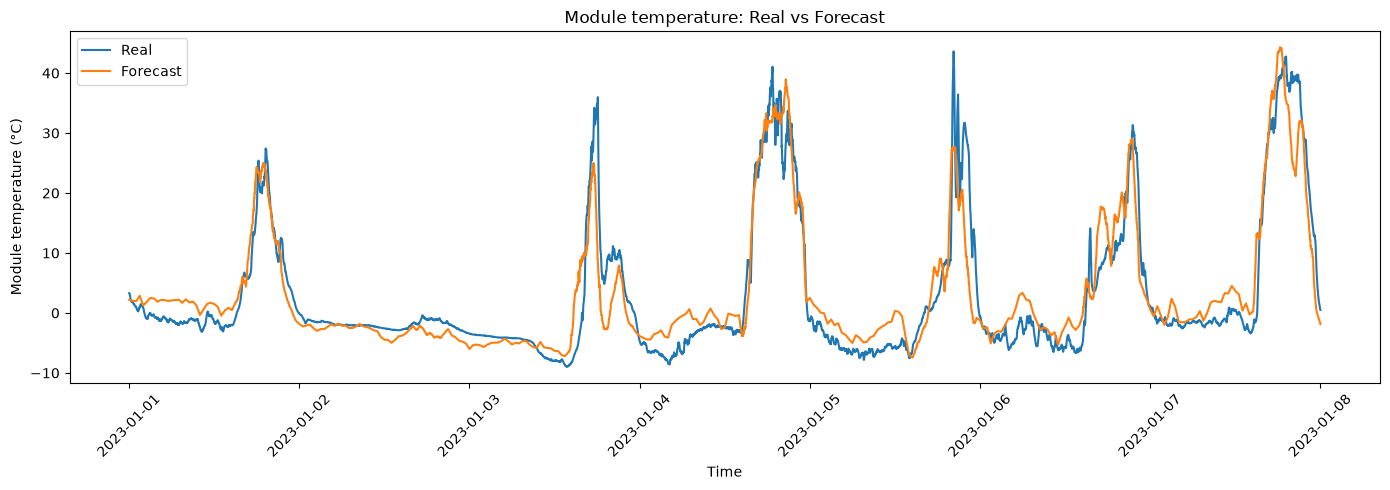

In [25]:
sample = df_forecast[
    df_forecast["forecast_date"]
    == df_forecast["forecast_date"].min()
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample["timestamp"],
    sample["module_temp_mean"],
    label="Real"
)

plt.plot(
    sample["timestamp"],
    sample["module_temp_mean_forecast"],
    label="Forecast"
)

plt.xlabel("Time")
plt.ylabel("Module temperature (°C)")
plt.title("Module temperature: Real vs Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

now let's see for irradiance

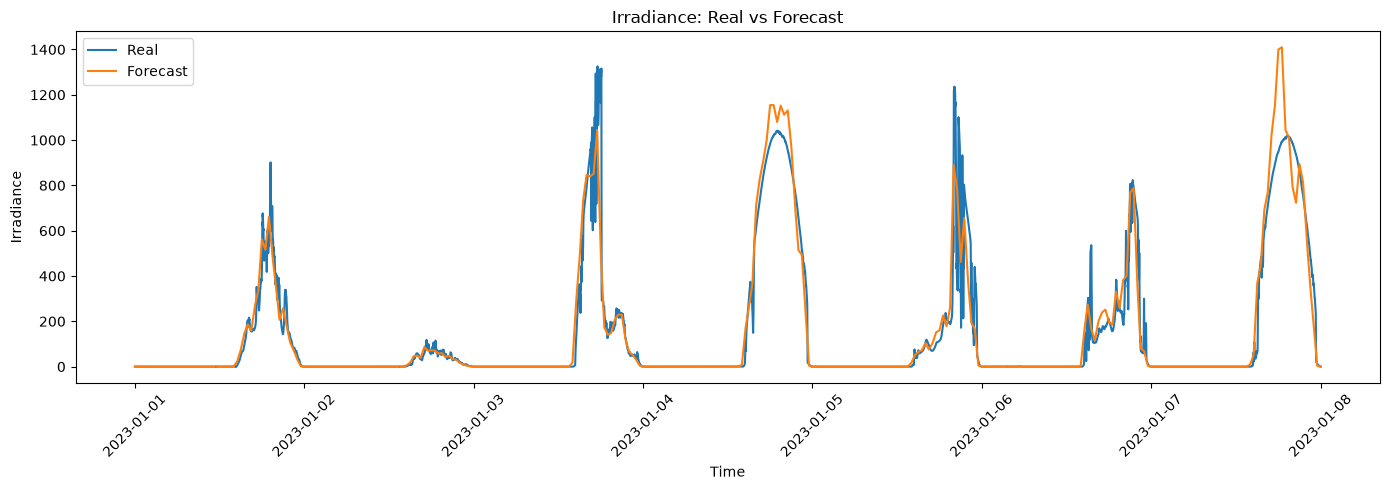

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample["timestamp"],
    sample["irradiance"],
    label="Real"
)

plt.plot(
    sample["timestamp"],
    sample["irradiance_forecast"],
    label="Forecast"
)

plt.xlabel("Time")
plt.ylabel("Irradiance")
plt.title("Irradiance: Real vs Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# ==================================================
# 1. Feature set used during model training
# ==================================================

df_forecast = df_forecast.rename(
    columns={
        "year_of_year_sin": "day_of_year_sin",
        "year_of_year_cos": "day_of_year_cos"
    }
)

forecast_features = [
    "irradiance_forecast",
    "ambient_temp_forecast",
    "module_temp_mean_forecast",
    "hour_sin",
    "hour_cos",
    "year_of_year_sin",
    "year_of_year_cos"
]


# ==================================================
# 2. Prepare forecast features
# ==================================================

# ==========================================
# Prepare forecast features
# ==========================================

forecast_features = [
    "irradiance_forecast",
    "ambient_temp_forecast",
    "module_temp_mean_forecast",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

X_forecast = df_forecast[forecast_features].copy()

# Rename forecast columns to training feature names
X_forecast.columns = [
    "irradiance",
    "ambient_temp",
    "module_temp_mean",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

# ==================================================
# 3. Scale using the scaler from training
# ==================================================

X_forecast_scaled = scaler_loaded.transform(X_forecast)


# ==================================================
# 4. Generate AC power predictions
# ==================================================

predictions = {}

predictions["Linear Regression"] = (
    lr_loaded.predict(X_forecast_scaled)
)

predictions["Random Forest"] = (
    rf_loaded.predict(X_forecast_scaled)
)

predictions["HistGradientBoosting"] = (
    hgb_loaded.predict(X_forecast_scaled)
)

predictions["XGBoost"] = (
    xgb_loaded.predict(X_forecast_scaled)
)

predictions["Neural Network"] = (
    nn_loaded.predict(
        X_forecast_scaled,
        verbose=0
    ).flatten()
)


# Add predictions to dataframe
for model_name, pred in predictions.items():
    df_forecast[f"ac_power_{model_name}"] = pred


# ==================================================
# 5. Calculate scores
# ==================================================

y_true = df_forecast["ac_power"].to_numpy()

scores = []

for model_name in predictions:

    y_pred = predictions[model_name]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    scores.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


scores_df = (
    pd.DataFrame(scores)
    .sort_values("MAE")
    .reset_index(drop=True)
)


# ==================================================
# 6. Display score table
# ==================================================

scores_df[
    ["Model", "MAE", "RMSE", "R²"]
].round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
})

/home/santi/solar-mlops/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/santi/solar-mlops/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/santi/solar-mlops/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,RMSE,R²
0,Neural Network,36.10,80.68,0.9156
1,HistGradientBoosting,150.22,310.42,-0.2498
2,Random Forest,152.51,316.80,-0.3017
3,XGBoost,154.82,318.85,-0.3186
4,Linear Regression,173.91,319.83,-0.3267


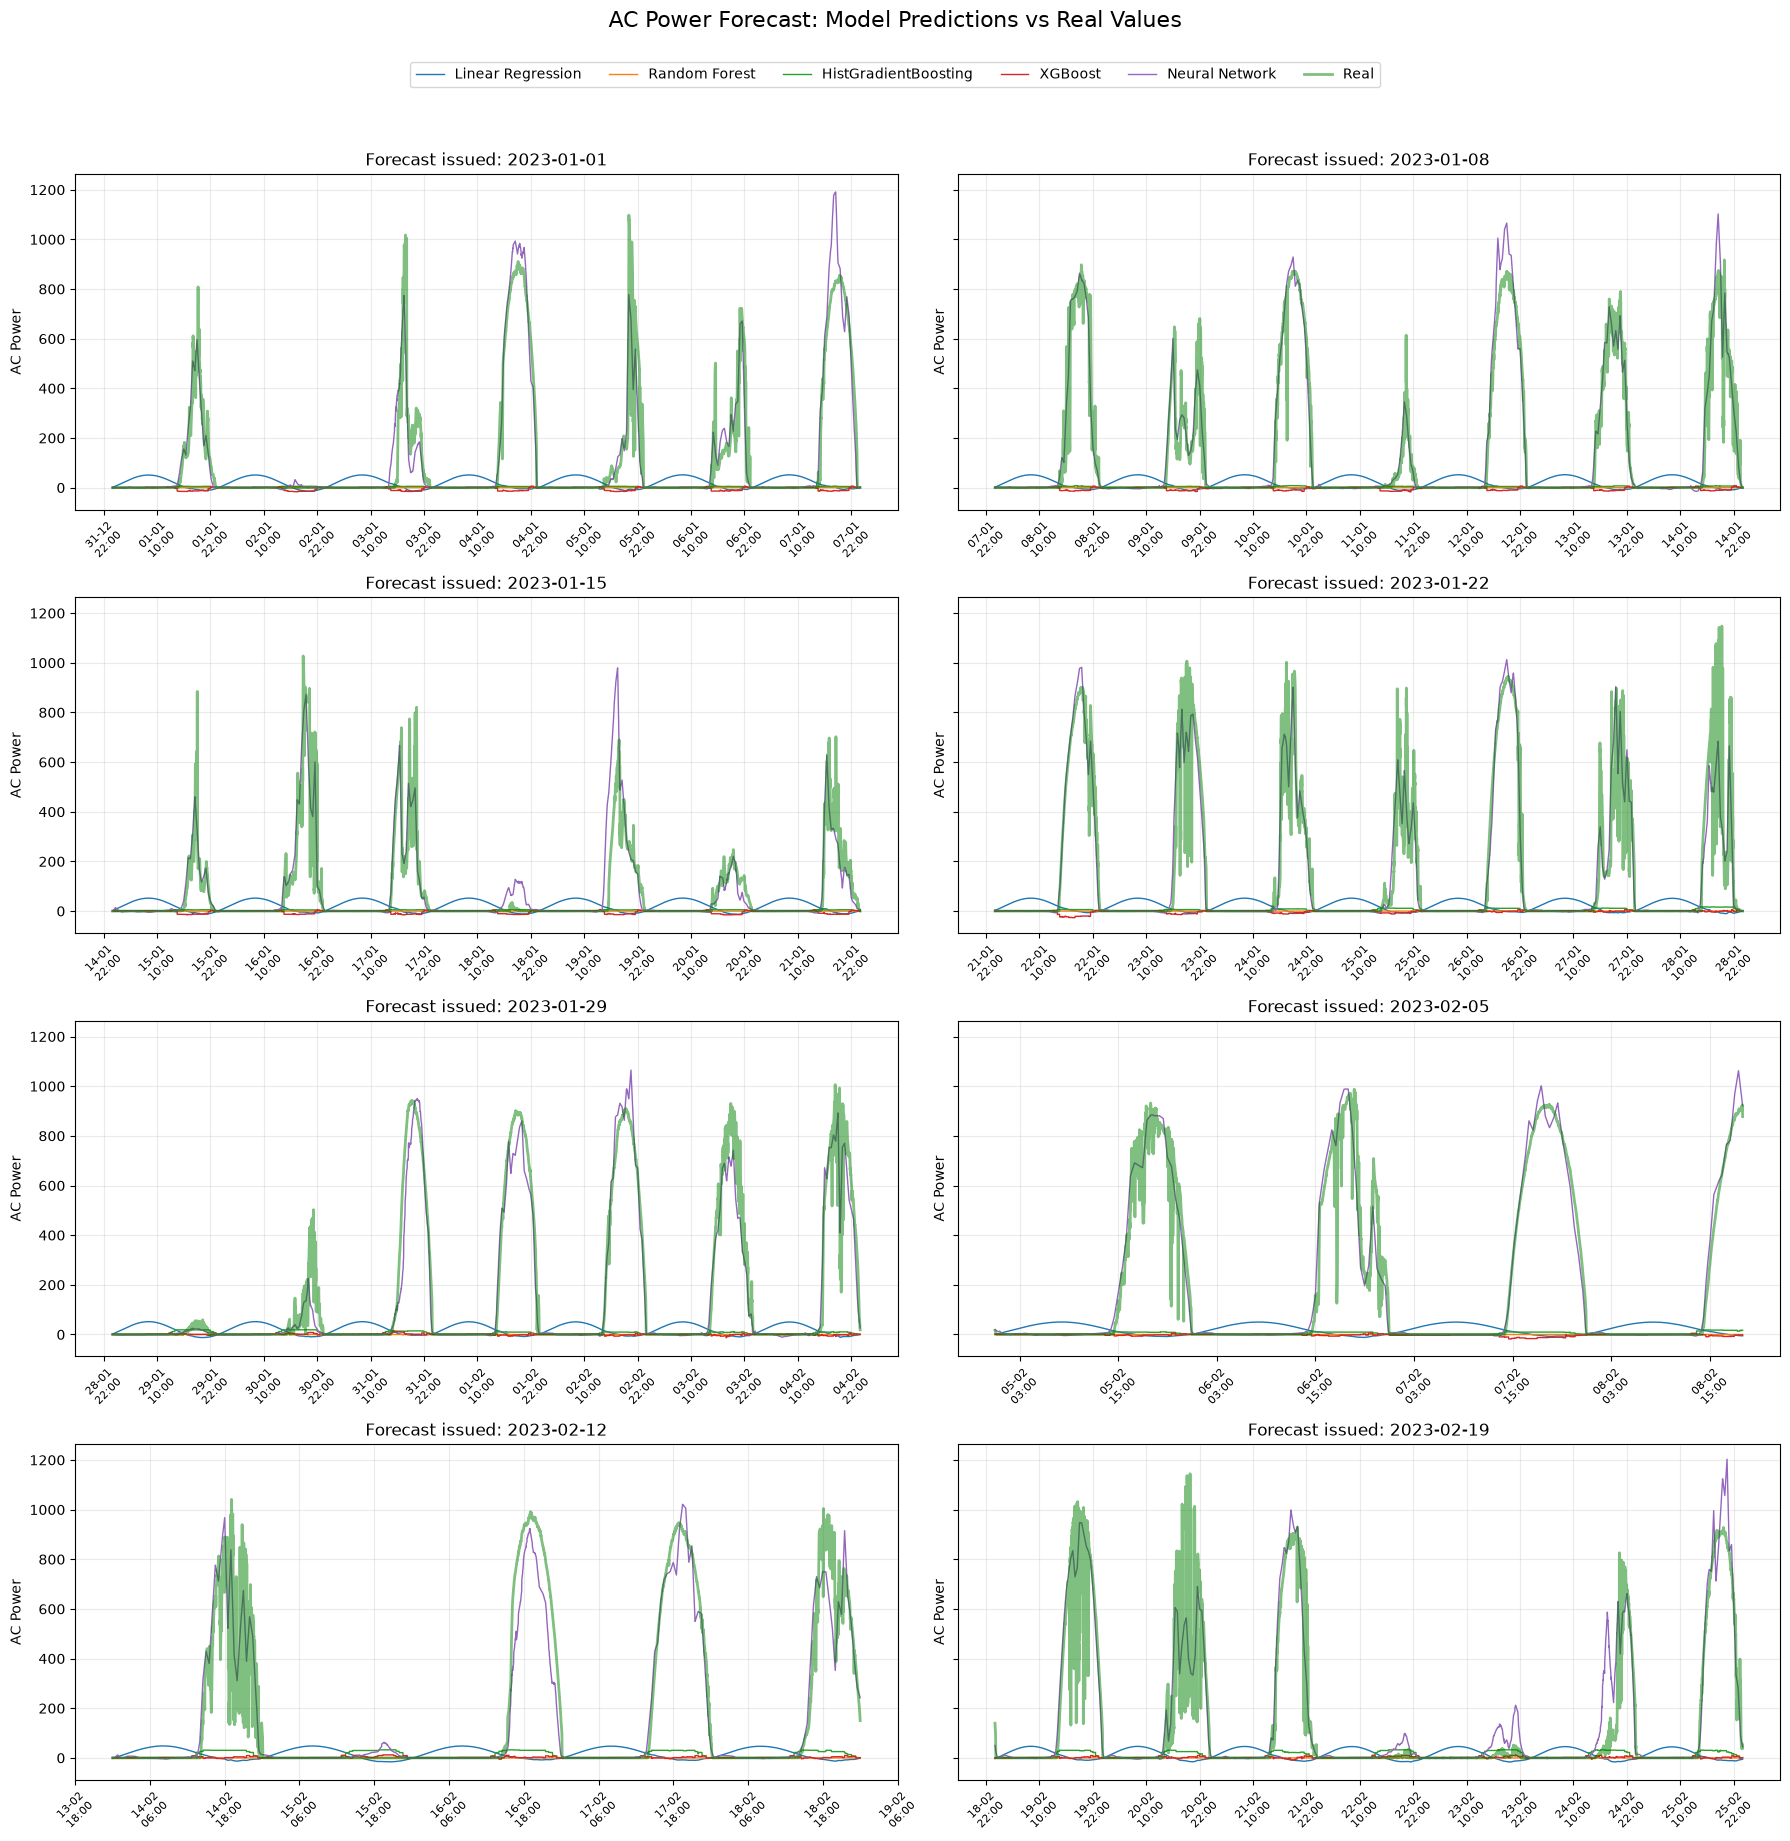

In [33]:
# ==================================================
# 7. Weekly plots
# ==================================================

model_names = [
    "Linear Regression",
    "Random Forest",
    "HistGradientBoosting",
    "XGBoost",
    "Neural Network"
]

# Prediction columns
prediction_columns = {
    "Linear Regression": "ac_power_Linear Regression",
    "Random Forest": "ac_power_Random Forest",
    "HistGradientBoosting": "ac_power_HistGradientBoosting",
    "XGBoost": "ac_power_XGBoost",
    "Neural Network": "ac_power_Neural Network"
}


# Get weekly forecast dates
weekly_dates = (
    df_forecast["forecast_date"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

# First 8 weeks
weekly_dates = weekly_dates[:8]


fig, axes = plt.subplots(
    4,
    2,
    figsize=(18, 18),
    sharey=True
)

axes = axes.flatten()


for ax, forecast_date in zip(axes, weekly_dates):

    # Select this forecast week
    week_data = df_forecast[
        df_forecast["forecast_date"] == forecast_date
    ].copy()

    week_data = week_data.sort_values("timestamp")

    # ----------------------------------------------
    # Plot model predictions
    # ----------------------------------------------

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power_Linear Regression"],
        label="Linear Regression",
        linewidth=1.0
    )

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power_Random Forest"],
        label="Random Forest",
        linewidth=1.0
    )

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power_HistGradientBoosting"],
        label="HistGradientBoosting",
        linewidth=1.0
    )

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power_XGBoost"],
        label="XGBoost",
        linewidth=1.0
    )

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power_Neural Network"],
        label="Neural Network",
        linewidth=1.0
    )

    # ----------------------------------------------
    # Plot REAL value last and above everything
    # ----------------------------------------------

    ax.plot(
        week_data["timestamp"],
        week_data["ac_power"],
        label="Real",
        linewidth=2.0,
        color="green",
        alpha=0.5,
        zorder=10
    )

    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------

    ax.set_title(
        f"Forecast issued: {pd.Timestamp(forecast_date):%Y-%m-%d}"
    )

    ax.set_ylabel("AC Power")

    ax.grid(
        True,
        alpha=0.25
    )

    # Avoid overlapping date labels
    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )

    # Automatically choose a manageable number of ticks
    ax.xaxis.set_major_locator(
        plt.matplotlib.dates.HourLocator(interval=12)
    )

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter("%d-%m\n%H:%M")
    )


# Turn off unused axes, if there are fewer than 8 weeks
for ax in axes[len(weekly_dates):]:
    ax.axis("off")


# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=6,
    bbox_to_anchor=(0.5, 0.995)
)

fig.suptitle(
    "AC Power Forecast: Model Predictions vs Real Values",
    fontsize=16,
    y=1.02
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [35]:

# ==================================================
# 1. Select real 2023 data
# ==================================================

df_real_23 = df[
    (df["timestamp"] >= "2023-01-01") &
    (df["timestamp"] < "2024-01-01")
][
    [
        "timestamp",
        "irradiance",
        "ambient_temp",
        "module_temp_mean",
        "ac_power"
    ]
].copy()


# ==================================================
# 2. Create cyclical time features
# ==================================================

# Hour of day
hour_decimal = (
    df_real_23["timestamp"].dt.hour
    + df_real_23["timestamp"].dt.minute / 60
)

df_real_23["hour_sin"] = np.sin(
    2 * np.pi * hour_decimal / 24
)

df_real_23["hour_cos"] = np.cos(
    2 * np.pi * hour_decimal / 24
)


# Day of year
day_of_year = df_real_23["timestamp"].dt.dayofyear

days_in_year = np.where(
    df_real_23["timestamp"].dt.is_leap_year,
    366,
    365
)

df_real_23["day_of_year_sin"] = np.sin(
    2 * np.pi * (day_of_year - 1) / days_in_year
)

df_real_23["day_of_year_cos"] = np.cos(
    2 * np.pi * (day_of_year - 1) / days_in_year
)


# ==================================================
# 3. Prepare features
# ==================================================

real_features = [
    "irradiance",
    "ambient_temp",
    "module_temp_mean",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

X_real_23 = df_real_23[real_features].copy()

y_real_23 = df_real_23["ac_power"].copy()


# ==================================================
# 4. Verify feature order
# ==================================================

print("Features expected by scaler:")
print(scaler_loaded.feature_names_in_)

print("\nFeatures being used:")
print(X_real_23.columns.tolist())


# ==================================================
# 5. Scale using the SAME scaler
# ==================================================

X_real_23_scaled = scaler_loaded.transform(
    X_real_23
)

# Preserve feature names after scaling
X_real_23_scaled = pd.DataFrame(
    X_real_23_scaled,
    columns=scaler_loaded.feature_names_in_,
    index=X_real_23.index
)


# ==================================================
# 6. Generate predictions
# ==================================================

real_predictions = {}

real_predictions["Linear Regression"] = (
    lr_loaded.predict(X_real_23_scaled)
)

real_predictions["Random Forest"] = (
    rf_loaded.predict(X_real_23_scaled)
)

real_predictions["HistGradientBoosting"] = (
    hgb_loaded.predict(X_real_23_scaled)
)

real_predictions["XGBoost"] = (
    xgb_loaded.predict(X_real_23_scaled)
)

real_predictions["Neural Network"] = (
    nn_loaded.predict(
        X_real_23_scaled,
        verbose=0
    ).flatten()
)


# ==================================================
# 7. Calculate scores
# ==================================================

scores_real = []

for model_name, y_pred in real_predictions.items():

    mae = mean_absolute_error(
        y_real_23,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real_23,
            y_pred
        )
    )

    r2 = r2_score(
        y_real_23,
        y_pred
    )

    scores_real.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


scores_real_df = (
    pd.DataFrame(scores_real)
    .sort_values("MAE")
    .reset_index(drop=True)
)


# ==================================================
# 8. Display results
# ==================================================

scores_real_df.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
})

Features expected by scaler:
['irradiance' 'ambient_temp' 'module_temp_mean' 'hour_sin' 'hour_cos'
 'day_of_year_sin' 'day_of_year_cos']

Features being used:
['irradiance', 'ambient_temp', 'module_temp_mean', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos']


,Model,MAE,RMSE,R²
0,Neural Network,11.78,28.74,0.9893
1,HistGradientBoosting,150.20,310.39,-0.2496
2,Random Forest,152.50,316.80,-0.3016
3,XGBoost,154.83,318.83,-0.3184
4,Linear Regression,173.56,319.61,-0.3249
